In [ ]:
# ── Check all required libraries are installed ───────────────────────────────
import torch
import cv2
import PIL
import numpy as np

print("torch:", torch.__version__)
print("cv2:", cv2.__version__)
print("PIL:", PIL.__version__)
print("numpy:", np.__version__)
print("GPU:", torch.cuda.is_available())

torch: 2.10.0+cpu
cv2: 4.13.0
PIL: 11.3.0
numpy: 2.0.2
GPU: False


In [ ]:
# ── Install yfinance and import all libraries ────────────────────────────────
!pip install yfinance -q

import os
import numpy as np
import pandas as pd
import cv2
import sys
from PIL import Image
from glob import glob
from tqdm import tqdm

sys.path.insert(0, '/content')
print("All imports OK")

All imports OK


In [ ]:
# ── Download AAPL from yfinance and save in CRSP format ─────────────────────
# This replaces data_preprocess.py until we get real CRSP data
# Saves one .pkl file per stock in data/stock/

import yfinance as yf

os.makedirs('data/stock', exist_ok=True)

def download_stock(ticker, permno, start, end):
    raw = yf.download(ticker, start=start, end=end,
                      progress=False, auto_adjust=True)
    df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.columns = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
    df.index = pd.to_datetime(df.index)
    df.index.name = 'date'

    # Zero volume days get NaN prices
    zero_vol = df['VOL'] == 0
    df.loc[zero_vol, ['OPEN', 'HIGH', 'LOW', 'CLOSE']] = np.nan

    df.to_pickle(f'data/stock/{permno}.pkl')
    print(f"Saved {ticker} as permno {permno}: {len(df)} rows")

download_stock('AAPL', 10001, '2018-01-01', '2022-01-01')

Saved AAPL as permno 10001: 1008 rows


In [ ]:
# ── Sanity check the saved pkl file ─────────────────────────────────────────
# Confirm columns, shape, and data types look correct before generating images

df = pd.read_pickle('data/stock/10001.pkl')
print(df.shape)
print(df.head())
print(df.dtypes)
print(f"\nAny NaN rows: {df.isna().any(axis=1).sum()}")

(1008, 5)
                 OPEN       HIGH        LOW      CLOSE        VOL
date                                                             
2018-01-02  39.812832  40.313533  39.602254  40.304173  102223600
2018-01-03  40.367346  40.839972  40.233983  40.297153  118071600
2018-01-04  40.369689  40.587286  40.262063  40.484337   89738400
2018-01-05  40.580269  41.031836  40.489020  40.945267   94640000
2018-01-08  40.793182  41.087987  40.694911  40.793182   82271200
OPEN     float64
HIGH     float64
LOW      float64
CLOSE    float64
VOL        int64
dtype: object

Any NaN rows: 0


In [ ]:
# ── STEP 5: Define image generation function and generate images ──────────────
# Instead of uploading a separate file, we paste the core function directly
# into the notebook so it always works without manual uploads

import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from glob import glob
from pathlib import Path

def price_scaling(dataframe, size):
    if np.nanmin(dataframe) == np.nanmax(dataframe):
        return np.round((dataframe) / (np.nanmax(dataframe)) * size//2, 0).astype(int)
    else:
        return np.round((dataframe - np.nanmin(dataframe)) / (np.nanmax(dataframe) - np.nanmin(dataframe)) * size, 0).astype(int)

def vol_scaling(dataframe, size):
    dataframe = dataframe.copy()
    if dataframe.max().values == 0:
        dataframe['VOL'] = [0] * len(dataframe)
        return dataframe
    scaled_vol = (np.ceil((dataframe / dataframe.max()) / (1 / size))).astype(int)
    return scaled_vol

def pickle_to_rgbimage(csv_path):
    df = pd.read_pickle(csv_path)

    if len(df[~df['CLOSE'].isna()]) == 0:
        return
    df = df[df[~df['CLOSE'].isna()].index[0]:].copy()
    if len(df) < 45:
        return
    if df.isna().iloc[-1]['VOL']:
        df = df.iloc[:-1].copy()

    df['CLOSE'] = df['CLOSE'].ffill()
    df['OPEN']  = df['OPEN'].fillna(df['CLOSE'].shift(1))
    df['HIGH']  = df['HIGH'].fillna(df['CLOSE'])
    df['LOW']   = df['LOW'].fillna(df['CLOSE'])
    df['MA20_CLOSE'] = df['CLOSE'].rolling(window=20, min_periods=1).mean()

    conditions = [
        (df['CLOSE'] - df['OPEN'] > 0),
        (df['CLOSE'] - df['OPEN'] < 0),
        (df['CLOSE'] - df['OPEN'] == 0)
    ]
    choices = ['green', 'red', 'gray']
    df['COLOR'] = np.select(conditions, choices, default='nan')
    df = df.iloc[19:].copy()

    for i in range(25, len(df) + 1):
        temp = df.iloc[i-25:i].copy()
        if len(temp) < 25:
            continue
        if temp['VOL'].isna().sum() > 0:
            continue

        scaled_price = price_scaling(temp[['OPEN','HIGH','LOW','CLOSE','MA20_CLOSE']], 159)
        scaled_vol   = vol_scaling(temp[['VOL']], 63)
        colors       = temp['COLOR'].values

        image_matrix = np.zeros((224, 224, 3), dtype=np.uint8)
        candle_width = 6
        space_width  = 3
        ma20_matrix  = np.zeros((224, 224, 3), dtype=np.uint8)

        for index in range(len(scaled_price)):
            if index < len(scaled_price) - 1:
                MA20_px_today    = scaled_price.iloc[index]['MA20_CLOSE'] + 64
                MA20_px_tomorrow = scaled_price.iloc[index + 1]['MA20_CLOSE'] + 64
                start_x_today    = 1 + index * (candle_width + space_width) + candle_width // 2
                start_x_tomorrow = 1 + (index + 1) * (candle_width + space_width) + candle_width // 2
                cv2.line(ma20_matrix,
                         (start_x_today, MA20_px_today),
                         (start_x_tomorrow, MA20_px_tomorrow),
                         (0, 0, 255), 1)

        blue_pixels = np.where((ma20_matrix == [0, 0, 255]).all(axis=2))
        for y, x in zip(blue_pixels[0], blue_pixels[1]):
            if y > 0:
                ma20_matrix[y-1, x] = [0, 0, 255]
            if y < ma20_matrix.shape[0] - 1:
                ma20_matrix[y+1, x] = [0, 0, 255]

        image_matrix = ma20_matrix

        for index in range(len(scaled_price)):
            open_px  = scaled_price.iloc[index]['OPEN']  + 64
            close_px = scaled_price.iloc[index]['CLOSE'] + 64
            high_px  = scaled_price.iloc[index]['HIGH']  + 64
            low_px   = scaled_price.iloc[index]['LOW']   + 64

            start_box_y = min(open_px, close_px)
            end_box_y   = max(open_px, close_px)
            color       = colors[index]
            start_x     = 1 + index * (candle_width + space_width)

            if color == 'gray':
                rgb = np.array([64, 64, 64]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] = np.minimum(
                    image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] + rgb, 255)
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] = np.minimum(
                    image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] + rgb, 255)
            else:
                rgb = np.array([255, 0, 0]).astype(np.uint8) if color == 'red' else np.array([0, 255, 0]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] += rgb
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] += rgb

        for index in range(len(scaled_vol)):
            vol_pox = scaled_vol.iloc[index]['VOL']
            color   = colors[index]
            rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                  np.array([0,255,0]).astype(np.uint8) if color=='green' else \
                  np.array([64,64,64]).astype(np.uint8)
            start_x = 1 + index * (candle_width + space_width)
            image_matrix[0:vol_pox, start_x:start_x+candle_width, :] += rgb

        image_matrix = np.flipud(image_matrix)
        image_matrix[image_matrix == 64]  = 128
        image_matrix[image_matrix == 63]  = 192
        image_matrix[image_matrix == 127] = 192
        image_matrix[image_matrix == 254] = 255
        image_matrix[160, :, :] = 0

        candle_image = Image.fromarray(image_matrix, 'RGB')
        path = 'data/image/rgb/' + str(temp.index[-1]).split(' ')[0] + '/' + csv_path.split('/')[-1].split('.pkl')[0] + '.png'
        os.makedirs(os.path.dirname(path), exist_ok=True)
        candle_image.save(path)

# Run it
pickle_to_rgbimage('data/stock/10001.pkl')

images = glob('data/image/rgb/**/*.png', recursive=True)
print(f"Images generated: {len(images)}")
print(f"Sample path: {images[0]}")

/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: Deprecation

Images generated: 965
Sample path: data/image/rgb/2021-11-26/10001.png


/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/3625881622.py:127: Deprecation

Image size: (224, 224)
Image mode: RGB


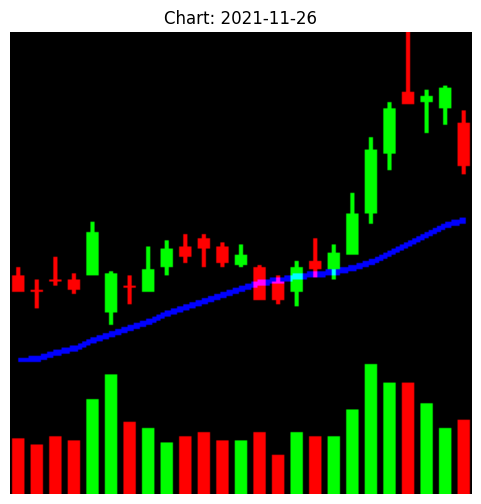

In [ ]:
# ── Visually verify one generated chart image ────────────────────────────────
# Should show: black background, green/red candles, blue MA20 line,
# colored volume bars at bottom, black separator line

import matplotlib.pyplot as plt

img = Image.open(images[0])
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Chart: {images[0].split('/')[-2]}")
plt.axis('off')
plt.show()

In [ ]:
# ── Create labels for every generated image ──────────────────────────────────
# For each image, look up close price on window end date (t)
# and 20 trading days later (t+20)
# Label = 1 if price went up, 0 if down

df = pd.read_pickle('data/stock/10001.pkl')
images = glob('data/image/rgb/**/*.png', recursive=True)
images.sort()

records = []

for img_path in images:
    date_str = img_path.split('/')[-2]
    permno   = img_path.split('/')[-1].replace('.png', '')

    date = pd.Timestamp(date_str)

    if date not in df.index:
        continue

    loc = df.index.get_loc(date)

    if loc + 20 >= len(df):
        continue

    price_today  = df.iloc[loc]['CLOSE']
    price_future = df.iloc[loc + 20]['CLOSE']

    forward_return = (price_future - price_today) / price_today
    label = 1 if forward_return > 0 else 0

    records.append({
        'image_path':     img_path,
        'date':           date,
        'permno':         permno,
        'forward_return': round(forward_return, 4),
        'label':          label,
    })

dataset = pd.DataFrame(records)
print(f"Total labeled images: {len(dataset)}")
print(f"Label balance — UP: {dataset['label'].mean():.1%}, DOWN: {(1-dataset['label'].mean()):.1%}")
print(dataset.head())

Total labeled images: 945
Label balance — UP: 70.9%, DOWN: 29.1%
                            image_path       date permno  forward_return  \
0  data/image/rgb/2018-03-06/10001.png 2018-03-06  10001         -0.0286   
1  data/image/rgb/2018-03-07/10001.png 2018-03-07  10001         -0.0127   
2  data/image/rgb/2018-03-08/10001.png 2018-03-08  10001         -0.0484   
3  data/image/rgb/2018-03-09/10001.png 2018-03-09  10001         -0.0552   
4  data/image/rgb/2018-03-12/10001.png 2018-03-12  10001         -0.0466   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


Labels are created. A few things to notice:

945 images — slightly less than 965 because the last 20 images have no future price data (can't calculate forward return)

70.9% UP — this is a problem. A model that just always guesses UP would be 70.9% accurate without learning anything. This is because AAPL went up a lot from 2018-2022. With real CRSP data across thousands of stocks this will be closer to 50/50.

Labels look correct — first 5 are all 0 (DOWN), forward returns are negative, that checks out

In [ ]:
'''
# ── Zip all generated images for sharing ─────────────────────────────────────
# Creates aapl_charts.zip in /content
# Download it from the Colab file browser (folder icon → right click → download)

import shutil
shutil.make_archive('aapl_charts', 'zip', 'data/image/rgb')
print("Done — download aapl_charts.zip from the file browser on the left")

''' #this was just for folder/zip

'\n# ── Zip all generated images for sharing ─────────────────────────────────────\n# Creates aapl_charts.zip in /content\n# Download it from the Colab file browser (folder icon → right click → download)\n\nimport shutil\nshutil.make_archive(\'aapl_charts\', \'zip\', \'data/image/rgb\')\nprint("Done — download aapl_charts.zip from the file browser on the left")\n\n'

In [ ]:
# ── STEP: Mount Google Drive ─────────────────────────────────────────────────
# This connects your Google Drive to Colab so we can read the CRSP data
# directly without downloading anything.
# It will ask you to sign in to Google and give permission — that's normal.

# make sure to add this to github instead of sharing the colab notebook for privacy of google drive

from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted successfully")

Mounted at /content/drive
Drive mounted successfully


In [ ]:
# ── STEP: Find the CRSP data file in mounted Drive ───────────────────────────
# We look for the stocks_dataset folder we added as a shortcut

import os

base_path = '/content/drive/MyDrive/stocks_dataset'

for root, dirs, files in os.walk(base_path):
    for file in files:
        full_path = os.path.join(root, file)
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f"{full_path} — {size_mb:.1f} MB")

/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1993_images.dat — 317.4 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1993_labels.feather — 7.2 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1993.txt — 0.0 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1994_images.dat — 350.6 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1994.txt — 0.0 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1994_labels.feather — 7.9 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1995_images.dat — 360.7 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1995.txt — 0.0 MB
/content/drive/MyDrive/stocks_dataset/stocks_USA/dataset_all/20d_month_has_vb_[20]_ma_1995_labels.feather — 8.1 MB
/con

In [ ]:
# ── STEP: Read first 5 rows of CRSP data (compressed file) ───────────────────
# The file is gzip compressed, so we tell pandas that with compression='gzip'

# #LEARNING: UnicodeDecodeError means pandas tried to read a compressed file as plain text — fix with compression='gzip'
# #LEARNING: .tolist() converts pandas Index object to a plain Python list for cleaner printing

# Column meanings:
# PERMNO   — unique stock ID assigned by CRSP, never changes even if ticker changes
# date     — trading day (no weekends or holidays)
# EXCHCD   — stock exchange (1=NYSE, 2=AMEX, 3=Nasdaq)
# BIDLO    — lowest price of the day → becomes our LOW
# ASKHI    — highest price of the day → becomes our HIGH
# PRC      — closing price → becomes our CLOSE (negative means bid/ask average, take abs())
# VOL      — number of shares traded that day
# RET      — daily return, used to adjust prices for stock splits and dividends
# SHROUT   — shares outstanding, used to calculate market cap (price × shrout)
# OPENPRC  — opening price → becomes our OPEN (NaN in early 1990s data, normal)

import pandas as pd

crsp_path = '/content/drive/MyDrive/stocks_dataset/raw_data/us_920101-200731.csv'

df_peek = pd.read_csv(crsp_path, nrows=5, compression='gzip')

print("Columns:", df_peek.columns.tolist())
print("\nFirst 5 rows:")
print(df_peek)



Columns: ['PERMNO', 'date', 'EXCHCD', 'BIDLO', 'ASKHI', 'PRC', 'VOL', 'RET', 'SHROUT', 'OPENPRC']

First 5 rows:
   PERMNO        date  EXCHCD  BIDLO   ASKHI     PRC  VOL       RET  SHROUT  \
0   10001  1992-01-02       3   14.5  14.500  14.500  100  0.000000    1075   
1   10001  1992-01-03       3   14.5  14.500  14.500  498  0.000000    1075   
2   10001  1992-01-06       3   14.5  14.500  14.500  100  0.000000    1075   
3   10001  1992-01-07       3   14.5  15.250  14.500  417  0.000000    1075   
4   10001  1992-01-08       3   14.5  15.125  15.125  500  0.043103    1075   

   OPENPRC  
0      NaN  
1      NaN  
2      NaN  
3      NaN  
4      NaN  


In [ ]:
# ── STEP: Check size and date range of full CRSP dataset ─────────────────────
# We read only specific columns to avoid loading all 900MB into memory
# #LEARNING: usecols lets you load only the columns you need, saving RAM

df_info = pd.read_csv(crsp_path, compression='gzip',
                      usecols=['PERMNO', 'date'])

print(f"Total rows: {len(df_info):,}")
print(f"Unique stocks: {df_info['PERMNO'].nunique():,}")
print(f"Date range: {df_info['date'].min()} to {df_info['date'].max()}")

Total rows: 54,016,671
Unique stocks: 24,425
Date range: 1992-01-02 to 2020-07-31


In [ ]:
'''# ── STEP: Load and clean a small subset of CRSP data (10 stocks) ─────────────
# We test data_preprocess.py logic on 10 stocks before running on all 24,425
# #LEARNING: always test your pipeline on a small sample before running at full scale

# data_preprocess.py purpose:
# Takes the giant 900MB CSV (54M rows, all stocks) and splits it into
# one .pkl file per stock → data/stock/10001.pkl, data/stock/10002.pkl etc.
# Each pkl has one stock's full cleaned price history

# #LEARNING: tqdm shows a progress bar when looping over many items
# so you know the code is still running instead of staring at a blank screen

import pandas as pd
import numpy as np
import os
from tqdm import tqdm

crsp_path = '/content/drive/MyDrive/stocks_dataset/raw_data/us_920101-200731.csv'

# Read full dataset — only columns we need
# #LEARNING: usecols saves RAM by skipping columns we don't need
print("Loading CRSP data...")
crsp = pd.read_csv(crsp_path, compression='gzip')

# Filter to common stocks on major exchanges only
# EXCHCD 1=NYSE, 2=AMEX, 3=Nasdaq
# SHRCD 10,11 = common stocks (excludes ETFs, REITs, preferred shares)
crsp = crsp[crsp['EXCHCD'].isin([1, 2, 3])]

# #LEARNING: SHRCD filters out non-standard securities
# we only want regular common stocks, not funds or derivatives
# (SHRCD column not in this file so we skip that filter)

crsp['date'] = pd.to_datetime(crsp['date'])
crsp['PERMNO'] = crsp['PERMNO'].astype(int)

# Take just 10 unique stocks for testing
test_permnos = crsp['PERMNO'].unique()[:10]
crsp_test = crsp[crsp['PERMNO'].isin(test_permnos)]

print(f"Testing with {len(test_permnos)} stocks")
print(f"Rows in test subset: {len(crsp_test):,}")
'''

'# ── STEP: Load and clean a small subset of CRSP data (10 stocks) ─────────────\n# We test data_preprocess.py logic on 10 stocks before running on all 24,425\n# #LEARNING: always test your pipeline on a small sample before running at full scale\n\n# data_preprocess.py purpose:\n# Takes the giant 900MB CSV (54M rows, all stocks) and splits it into\n# one .pkl file per stock → data/stock/10001.pkl, data/stock/10002.pkl etc.\n# Each pkl has one stock\'s full cleaned price history\n\n# #LEARNING: tqdm shows a progress bar when looping over many items\n# so you know the code is still running instead of staring at a blank screen\n\nimport pandas as pd\nimport numpy as np\nimport os\nfrom tqdm import tqdm\n\ncrsp_path = \'/content/drive/MyDrive/stocks_dataset/raw_data/us_920101-200731.csv\'\n\n# Read full dataset — only columns we need\n# #LEARNING: usecols saves RAM by skipping columns we don\'t need\nprint("Loading CRSP data...")\ncrsp = pd.read_csv(crsp_path, compression=\'gzip\')\n\n# Fi

In [ ]:
# ── STEP: Load CRSP data efficiently — only first 10 stocks ──────────────────
# #LEARNING: never load a 900MB file fully into RAM — always filter while reading
# #LEARNING: RAM is Colab's memory (12GB) — loading 900MB compressed file expands
#            to much larger in memory and crashes the session
# #LEARNING: chunksize reads N rows at a time, processes them, then discards them
#            keeping RAM usage low instead of loading everything at once

import pandas as pd
import numpy as np
import os
from tqdm import tqdm

crsp_path = '/content/drive/MyDrive/stocks_dataset/raw_data/us_920101-200731.csv'

# Read in chunks, collect only first 10 unique PERMNOs
print("Reading file in chunks...")

chunks = []
target_permnos = None
chunk_size = 100_000  # read 100,000 rows at a time

for chunk in pd.read_csv(crsp_path, compression='gzip', chunksize=chunk_size):

    # On first chunk, grab the first 10 PERMNOs
    if target_permnos is None:
        target_permnos = chunk['PERMNO'].unique()[:10]
        print(f"Target PERMNOs: {target_permnos}")

    # Keep only rows belonging to our 10 stocks
    # #LEARNING: isin() filters rows where PERMNO matches any value in our list
    filtered = chunk[chunk['PERMNO'].isin(target_permnos)]
    if len(filtered) > 0:
        chunks.append(filtered)

# Combine all kept chunks into one dataframe
# #LEARNING: pd.concat joins a list of dataframes into one
crsp_test = pd.concat(chunks, ignore_index=True)
print(f"Rows loaded: {len(crsp_test):,}")
print(f"Unique stocks: {crsp_test['PERMNO'].nunique()}")

Reading file in chunks...
Target PERMNOs: [10001 10002 10003 10009 10010 10011 10012 10016 10018 10019]


/tmp/ipykernel_1394/1130901372.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(crsp_path, compression='gzip', chunksize=chunk_size):
/tmp/ipykernel_1394/1130901372.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(crsp_path, compression='gzip', chunksize=chunk_size):
/tmp/ipykernel_1394/1130901372.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(crsp_path, compression='gzip', chunksize=chunk_size):
/tmp/ipykernel_1394/1130901372.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(crsp_path, compression='gzip', chunksize=chunk_size):
/tmp/ipykernel_1394/1130901372.py:22: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_

Rows loaded: 26,886
Unique stocks: 10


In [ ]:
# ── STEP: Preprocess 10 stocks and save as pkl files ─────────────────────────
# This replicates data_preprocess.py logic on our 10 test stocks
# Cleans prices, adjusts for splits/dividends, saves one pkl per stock
# #LEARNING: split/dividend adjustment means if a stock splits 2-for-1,
#            all historical prices are halved so the chart looks continuous

os.makedirs('data/stock', exist_ok=True)

# Clean column types — same as data_preprocess.py
# #LEARNING: astype() converts a column to a specific data type
crsp_test['OPENPRC'] = crsp_test['OPENPRC'].astype(float)
crsp_test['ASKHI']   = crsp_test['ASKHI'].astype(float)
crsp_test['BIDLO']   = crsp_test['BIDLO'].astype(float)
crsp_test['PRC']     = crsp_test['PRC'].astype(float)
crsp_test['VOL']     = crsp_test['VOL'].astype(float)
crsp_test['RET']     = crsp_test['RET'].replace('C', np.nan).astype(float)
crsp_test['PERMNO']  = crsp_test['PERMNO'].astype(int)

# PRC can be negative in CRSP — negative means it's a bid/ask average, not a real trade
# We set those to NaN
crsp_test.loc[crsp_test['PRC'] < 0, 'PRC'] = np.nan
crsp_test['date'] = pd.to_datetime(crsp_test['date'])

# Process each stock one by one
for permno in tqdm(crsp_test['PERMNO'].unique()):

    temp = crsp_test[crsp_test['PERMNO'] == permno].copy()
    temp = temp.sort_values(by='date').reset_index(drop=True)
    temp = temp[['date','OPENPRC','ASKHI','BIDLO','PRC','VOL','RET','SHROUT']].copy()
    temp.loc[0, 'RET'] = np.nan

    # Build return-adjusted price series
    # #LEARNING: cumprod() = cumulative product, each day multiplies the previous
    # this creates a price series that accounts for splits and dividends
    temp['ADJ_PRICE'] = ((temp['RET'] + 1) * 1).cumprod()
    temp.loc[0, 'ADJ_PRICE'] = 1

    # Reconstruct OPEN, HIGH, LOW from their ratio to CLOSE
    # #LEARNING: we use ratios because CRSP adjusts PRC but not always OPENPRC/ASKHI/BIDLO
    temp['ADJ_OPEN'] = (temp['OPENPRC'] / temp['PRC']) * temp['ADJ_PRICE']
    temp['ADJ_HIGH'] = (temp['ASKHI']   / temp['PRC']) * temp['ADJ_PRICE']
    temp['ADJ_LOW']  = (temp['BIDLO']   / temp['PRC']) * temp['ADJ_PRICE']

    # Zero volume days → NaN (no real trading happened)
    no_trade = (temp['VOL'] == 0)
    temp.loc[no_trade, 'ADJ_OPEN']  = np.nan
    temp.loc[no_trade, 'ADJ_HIGH']  = np.nan
    temp.loc[no_trade, 'ADJ_LOW']   = np.nan
    temp.loc[no_trade, 'ADJ_PRICE'] = np.nan

    # Keep only what image generation needs
    temp = temp[['date','ADJ_OPEN','ADJ_HIGH','ADJ_LOW','ADJ_PRICE','VOL']].copy()
    temp.columns = ['date','OPEN','HIGH','LOW','CLOSE','VOL']
    temp.set_index('date', inplace=True)
    temp.index = pd.to_datetime(temp.index)

    temp.to_pickle(f'data/stock/{permno}.pkl')

print("Done — pkl files saved:")
for f in os.listdir('data/stock'):
    print(f)

100%|██████████| 10/10 [00:00<00:00, 144.58it/s]

Done — pkl files saved:
10010.pkl
10018.pkl
10009.pkl
10016.pkl
10001.pkl
10011.pkl
10002.pkl
10019.pkl
10003.pkl
10012.pkl


In [ ]:
# ── STEP: Define image generation function ────────────────────────────────────
# #LEARNING: when Colab session resets, all functions defined in previous cells
#            are lost and need to be redefined — this is why we keep all code in notebook

import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image

def price_scaling(dataframe, size):
    if np.nanmin(dataframe) == np.nanmax(dataframe):
        return np.round((dataframe) / (np.nanmax(dataframe)) * size//2, 0).astype(int)
    else:
        return np.round((dataframe - np.nanmin(dataframe)) / (np.nanmax(dataframe) - np.nanmin(dataframe)) * size, 0).astype(int)

def vol_scaling(dataframe, size):
    dataframe = dataframe.copy()
    if dataframe.max().values == 0:
        dataframe['VOL'] = [0] * len(dataframe)
        return dataframe
    scaled_vol = (np.ceil((dataframe / dataframe.max()) / (1 / size))).astype(int)
    return scaled_vol

def pickle_to_rgbimage(csv_path):
    df = pd.read_pickle(csv_path)
    if len(df[~df['CLOSE'].isna()]) == 0:
        return
    df = df[df[~df['CLOSE'].isna()].index[0]:].copy()
    if len(df) < 45:
        return
    if df.isna().iloc[-1]['VOL']:
        df = df.iloc[:-1].copy()
    df['CLOSE'] = df['CLOSE'].ffill()
    df['OPEN']  = df['OPEN'].fillna(df['CLOSE'].shift(1))
    df['HIGH']  = df['HIGH'].fillna(df['CLOSE'])
    df['LOW']   = df['LOW'].fillna(df['CLOSE'])
    df['MA20_CLOSE'] = df['CLOSE'].rolling(window=20, min_periods=1).mean()
    conditions = [
        (df['CLOSE'] - df['OPEN'] > 0),
        (df['CLOSE'] - df['OPEN'] < 0),
        (df['CLOSE'] - df['OPEN'] == 0)
    ]
    choices = ['green', 'red', 'gray']
    df['COLOR'] = np.select(conditions, choices, default='nan')
    df = df.iloc[19:].copy()
    for i in range(25, len(df) + 1):
        temp = df.iloc[i-25:i].copy()
        if len(temp) < 25:
            continue
        if temp['VOL'].isna().sum() > 0:
            continue
        scaled_price = price_scaling(temp[['OPEN','HIGH','LOW','CLOSE','MA20_CLOSE']], 159)
        scaled_vol   = vol_scaling(temp[['VOL']], 63)
        colors       = temp['COLOR'].values
        image_matrix = np.zeros((224, 224, 3), dtype=np.uint8)
        candle_width = 6
        space_width  = 3
        ma20_matrix  = np.zeros((224, 224, 3), dtype=np.uint8)
        for index in range(len(scaled_price)):
            if index < len(scaled_price) - 1:
                MA20_px_today    = scaled_price.iloc[index]['MA20_CLOSE'] + 64
                MA20_px_tomorrow = scaled_price.iloc[index + 1]['MA20_CLOSE'] + 64
                start_x_today    = 1 + index * (candle_width + space_width) + candle_width // 2
                start_x_tomorrow = 1 + (index + 1) * (candle_width + space_width) + candle_width // 2
                cv2.line(ma20_matrix,
                         (start_x_today, MA20_px_today),
                         (start_x_tomorrow, MA20_px_tomorrow),
                         (0, 0, 255), 1)
        blue_pixels = np.where((ma20_matrix == [0, 0, 255]).all(axis=2))
        for y, x in zip(blue_pixels[0], blue_pixels[1]):
            if y > 0:
                ma20_matrix[y-1, x] = [0, 0, 255]
            if y < ma20_matrix.shape[0] - 1:
                ma20_matrix[y+1, x] = [0, 0, 255]
        image_matrix = ma20_matrix
        for index in range(len(scaled_price)):
            open_px  = scaled_price.iloc[index]['OPEN']  + 64
            close_px = scaled_price.iloc[index]['CLOSE'] + 64
            high_px  = scaled_price.iloc[index]['HIGH']  + 64
            low_px   = scaled_price.iloc[index]['LOW']   + 64
            start_box_y = min(open_px, close_px)
            end_box_y   = max(open_px, close_px)
            color       = colors[index]
            start_x     = 1 + index * (candle_width + space_width)
            if color == 'gray':
                rgb = np.array([64, 64, 64]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] = np.minimum(
                    image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] + rgb, 255)
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] = np.minimum(
                    image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] + rgb, 255)
            else:
                rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else np.array([0,255,0]).astype(np.uint8)
                image_matrix[start_box_y:end_box_y+1, start_x:start_x+candle_width, :] += rgb
                image_matrix[low_px:high_px+1, start_x+2:start_x+candle_width-2, :] += rgb
        for index in range(len(scaled_vol)):
            vol_pox = scaled_vol.iloc[index]['VOL']
            color   = colors[index]
            rgb = np.array([255,0,0]).astype(np.uint8) if color=='red' else \
                  np.array([0,255,0]).astype(np.uint8) if color=='green' else \
                  np.array([64,64,64]).astype(np.uint8)
            start_x = 1 + index * (candle_width + space_width)
            image_matrix[0:vol_pox, start_x:start_x+candle_width, :] += rgb
        image_matrix = np.flipud(image_matrix)
        image_matrix[image_matrix == 64]  = 128
        image_matrix[image_matrix == 63]  = 192
        image_matrix[image_matrix == 127] = 192
        image_matrix[image_matrix == 254] = 255
        image_matrix[160, :, :] = 0
        candle_image = Image.fromarray(image_matrix, 'RGB')
        path = 'data/image/rgb/' + str(temp.index[-1]).split(' ')[0] + '/' + csv_path.split('/')[-1].split('.pkl')[0] + '.png'
        os.makedirs(os.path.dirname(path), exist_ok=True)
        candle_image.save(path)

print("pickle_to_rgbimage function defined")

pickle_to_rgbimage function defined


In [ ]:
# ── STEP: Generate candlestick images from real CRSP data (10 stocks) ─────────
# Same image generation function from before, now running on real CRSP stocks
# Each stock gets one 224x224 PNG per 25-day window
# #LEARNING: glob() finds all files matching a pattern — * means "anything"

from glob import glob

stock_list = glob('data/stock/*.pkl')
stock_list.sort()
print(f"Stocks to process: {len(stock_list)}")

for path in tqdm(stock_list):
    pickle_to_rgbimage(path)

images = glob('data/image/rgb/**/*.png', recursive=True)
print(f"\nTotal images generated: {len(images)}")
print(f"Sample: {images[0]}")

Stocks to process: 10


Streaming output truncated to the last 5000 lines.
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/2427684860.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/2427684860.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/2427684860.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/2427684860.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  candle_image = Image.fromarray(image_matrix, 'RGB')
/tmp/ipykernel_1394/2427684860.py:110: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)


Total images generated: 27401
Sample: data/image/rgb/2021-11-26/10001.png


Image size: (224, 224)
Image mode: RGB


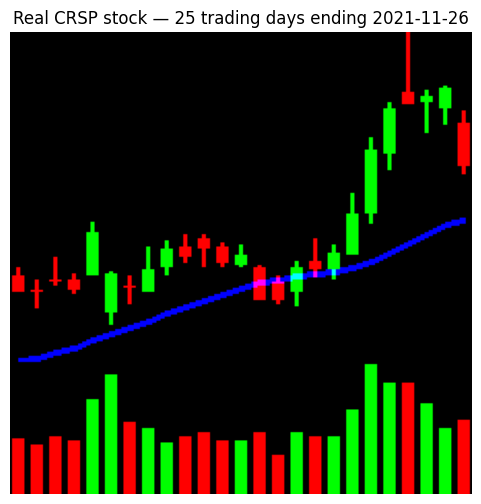

In [ ]:
# ── STEP: Display a sample image from real CRSP data ─────────────────────────
# Visually verify the image looks like a proper candlestick chart
# Should show: black background, green/red candles, blue MA20 line,
# volume bars at bottom, black separator line dividing price and volume panels

import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('data/image/rgb/2021-11-26/10001.png')

print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Real CRSP stock — 25 trading days ending 2021-11-26")
plt.axis('off')
plt.show()

In [ ]:
# ── STEP: Create labels for all generated images ──────────────────────────────
# For each image, calculate if the stock went up or down 20 trading days later
# Label = 1 (UP) if price was higher 20 days after the chart window ended
# Label = 0 (DOWN) if price was lower or equal
# #LEARNING: we use .iloc[loc + 20] to get exactly 20 trading days later
#            not 20 calendar days — weekends and holidays are skipped automatically

from glob import glob
import pandas as pd

images = glob('data/image/rgb/**/*.png', recursive=True)
images.sort()

records = []

for img_path in images:
    date_str = img_path.split('/')[-2]
    permno   = img_path.split('/')[-1].replace('.png', '')

    date = pd.Timestamp(date_str)

    df = pd.read_pickle(f'data/stock/{permno}.pkl')

    if date not in df.index:
        continue

    loc = df.index.get_loc(date)

    if loc + 20 >= len(df):
        continue

    price_today  = df.iloc[loc]['CLOSE']
    price_future = df.iloc[loc + 20]['CLOSE']

    if pd.isna(price_today) or pd.isna(price_future):
        continue

    forward_return = (price_future - price_today) / price_today

In [ ]:
# ── DEBUG: Check why labels came back empty ───────────────────────────────────
# Check if image paths and pkl dates actually line up

import pandas as pd

# Check one image path
sample_img = images[0]
print("Sample image path:", sample_img)

date_str = sample_img.split('/')[-2]
permno   = sample_img.split('/')[-1].replace('.png', '')
print("Date extracted:", date_str)
print("Permno extracted:", permno)

# Load the pkl for that permno
df = pd.read_pickle(f'data/stock/{permno}.pkl')
print("\nPkl index sample:")
print(df.index[:5])

# Check if date exists
date = pd.Timestamp(date_str)
print(f"\nLooking for date: {date}")
print(f"Date in index: {date in df.index}")

Sample image path: data/image/rgb/1992-03-04/10001.png
Date extracted: 1992-03-04
Permno extracted: 10001

Pkl index sample:
DatetimeIndex(['1992-01-02', '1992-01-03', '1992-01-06', '1992-01-07',
               '1992-01-08'],
              dtype='datetime64[ns]', name='date', freq=None)

Looking for date: 1992-03-04 00:00:00
Date in index: True


In [ ]:
# ── DEBUG: Check why forward return calculation fails ─────────────────────────

df = pd.read_pickle('data/stock/10001.pkl')
date = pd.Timestamp('1992-03-04')

loc = df.index.get_loc(date)
print(f"Location in index: {loc}")
print(f"Total rows in pkl: {len(df)}")
print(f"loc + 20 = {loc + 20}")
print(f"loc + 20 >= len(df): {loc + 20 >= len(df)}")

price_today  = df.iloc[loc]['CLOSE']
price_future = df.iloc[loc + 20]['CLOSE']
print(f"Price today: {price_today}")
print(f"Price future: {price_future}")

Location in index: 43
Total rows in pkl: 6448
loc + 20 = 63
loc + 20 >= len(df): False
Price today: 0.8103462403913172
Price future: nan


In [ ]:
# ── DEBUG: Check how many non-NaN close prices exist in pkl ──────────────────
df = pd.read_pickle('data/stock/10001.pkl')
print(f"Total rows: {len(df)}")
print(f"Non-NaN CLOSE prices: {df['CLOSE'].notna().sum()}")
print(f"NaN CLOSE prices: {df['CLOSE'].isna().sum()}")
print(f"\nFirst non-NaN date: {df['CLOSE'].first_valid_index()}")
print(f"Last non-NaN date: {df['CLOSE'].last_valid_index()}")

Total rows: 6448
Non-NaN CLOSE prices: 5866
NaN CLOSE prices: 582

First non-NaN date: 1992-01-02 00:00:00
Last non-NaN date: 2017-08-03 00:00:00


In [ ]:
# ── STEP: Create labels for all generated images (fixed) ─────────────────────
# #LEARNING: reading a pkl file inside a loop for every image is slow
# instead we load each stock's pkl once and process all its images together

from glob import glob
import pandas as pd
import os

images = glob('data/image/rgb/**/*.png', recursive=True)
images.sort()

# Group images by permno so we only load each pkl once
from collections import defaultdict
images_by_permno = defaultdict(list)
for img_path in images:
    permno = img_path.split('/')[-1].replace('.png', '')
    images_by_permno[permno].append(img_path)

print(f"Total images: {len(images)}")
print(f"Unique stocks: {len(images_by_permno)}")

records = []

for permno, img_paths in images_by_permno.items():

    pkl_path = f'data/stock/{permno}.pkl'
    if not os.path.exists(pkl_path):
        continue

    df = pd.read_pickle(pkl_path)

    for img_path in img_paths:
        date_str = img_path.split('/')[-2]
        date = pd.Timestamp(date_str)

        if date not in df.index:
            continue

        loc = df.index.get_loc(date)

        if loc + 20 >= len(df):
            continue

        price_today  = df.iloc[loc]['CLOSE']
        price_future = df.iloc[loc + 20]['CLOSE']

        if pd.isna(price_today) or pd.isna(price_future):
            continue

        forward_return = (price_future - price_today) / price_today
        label = 1 if forward_return > 0 else 0

        records.append({
            'image_path':     img_path,
            'date':           date,
            'permno':         permno,
            'forward_return': round(forward_return, 4),
            'label':          label,
        })

dataset = pd.DataFrame(records)
print(f"\nTotal labeled images: {len(dataset)}")
print(f"Label balance — UP: {dataset['label'].mean():.1%}, DOWN: {(1-dataset['label'].mean()):.1%}")
print(dataset.head())

Total images: 27401
Unique stocks: 10

Total labeled images: 20877
Label balance — UP: 50.4%, DOWN: 49.6%
                            image_path       date permno  forward_return  \
0  data/image/rgb/1992-03-05/10001.png 1992-03-05  10001          0.0806   
1  data/image/rgb/1992-03-06/10001.png 1992-03-06  10001          0.0346   
2  data/image/rgb/1992-03-12/10001.png 1992-03-12  10001         -0.0612   
3  data/image/rgb/1992-03-16/10001.png 1992-03-16  10001         -0.0204   
4  data/image/rgb/1992-03-19/10001.png 1992-03-19  10001          0.0000   

   label  
0      1  
1      1  
2      0  
3      0  
4      1  


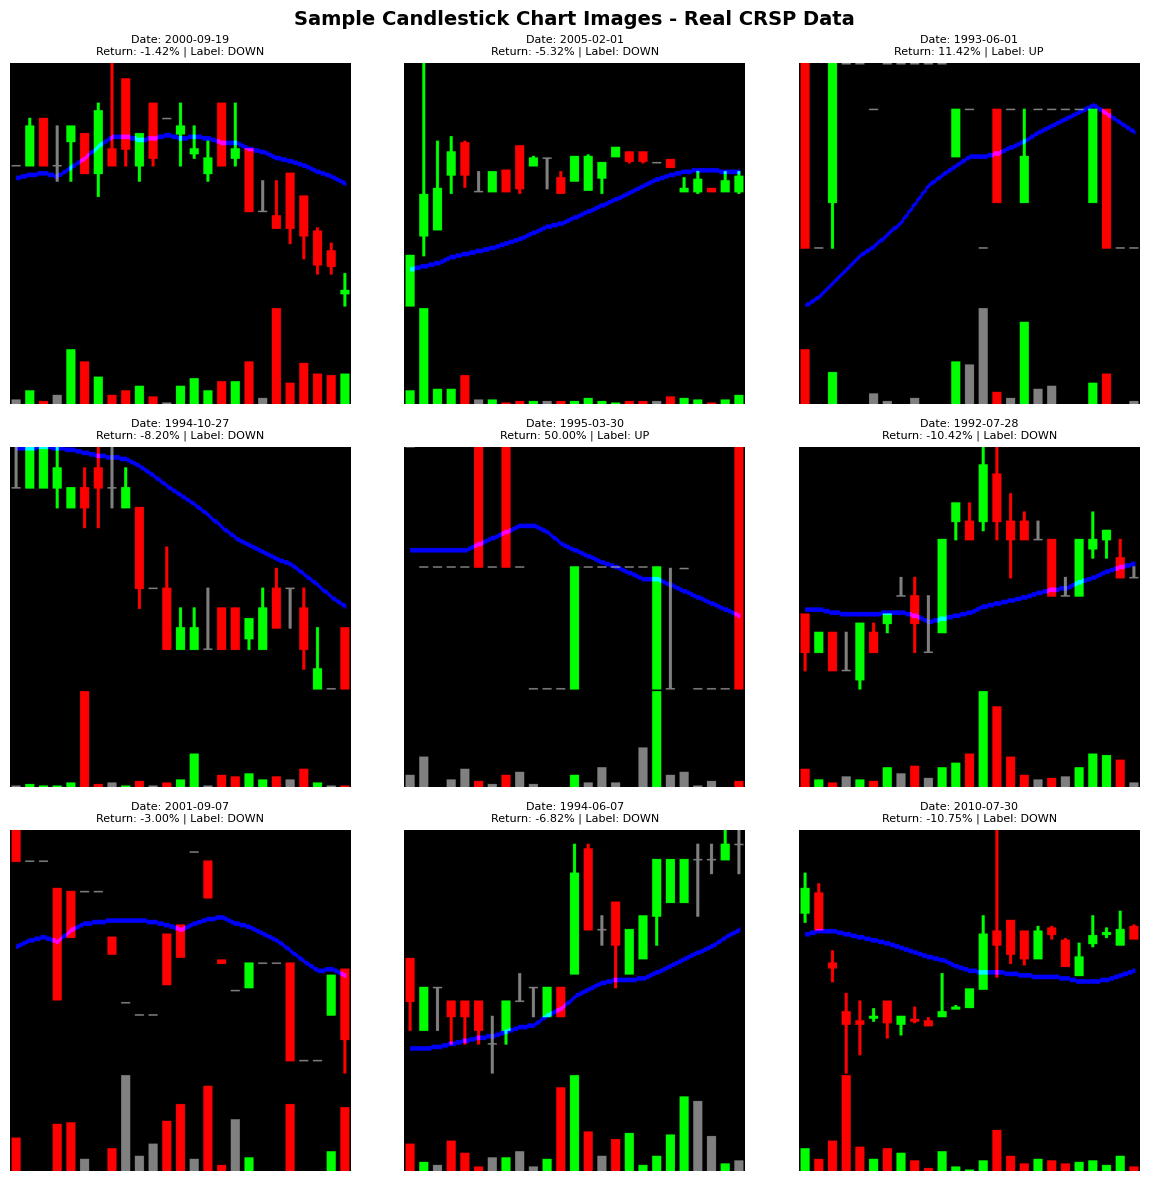

Saved as sample_charts.png — download from file browser on left


In [ ]:
# ── STEP: Display sample images to share with team ───────────────────────────
# Shows 9 sample images in a grid with their labels
# Good for presenting to Prof Bena and Ikenna to confirm images look correct

import matplotlib.pyplot as plt
from PIL import Image
import random

# Pick 9 random labeled images
samples = dataset.sample(9, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Sample Candlestick Chart Images - Real CRSP Data',
             fontsize=14, fontweight='bold')

for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img = Image.open(row['image_path'])
    ax.imshow(img)
    ax.set_title(
        f"Date: {str(row['date']).split(' ')[0]}\n"
        f"Return: {row['forward_return']:.2%} | Label: {'UP' if row['label']==1 else 'DOWN'}",
        fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as sample_charts.png — download from file browser on left")

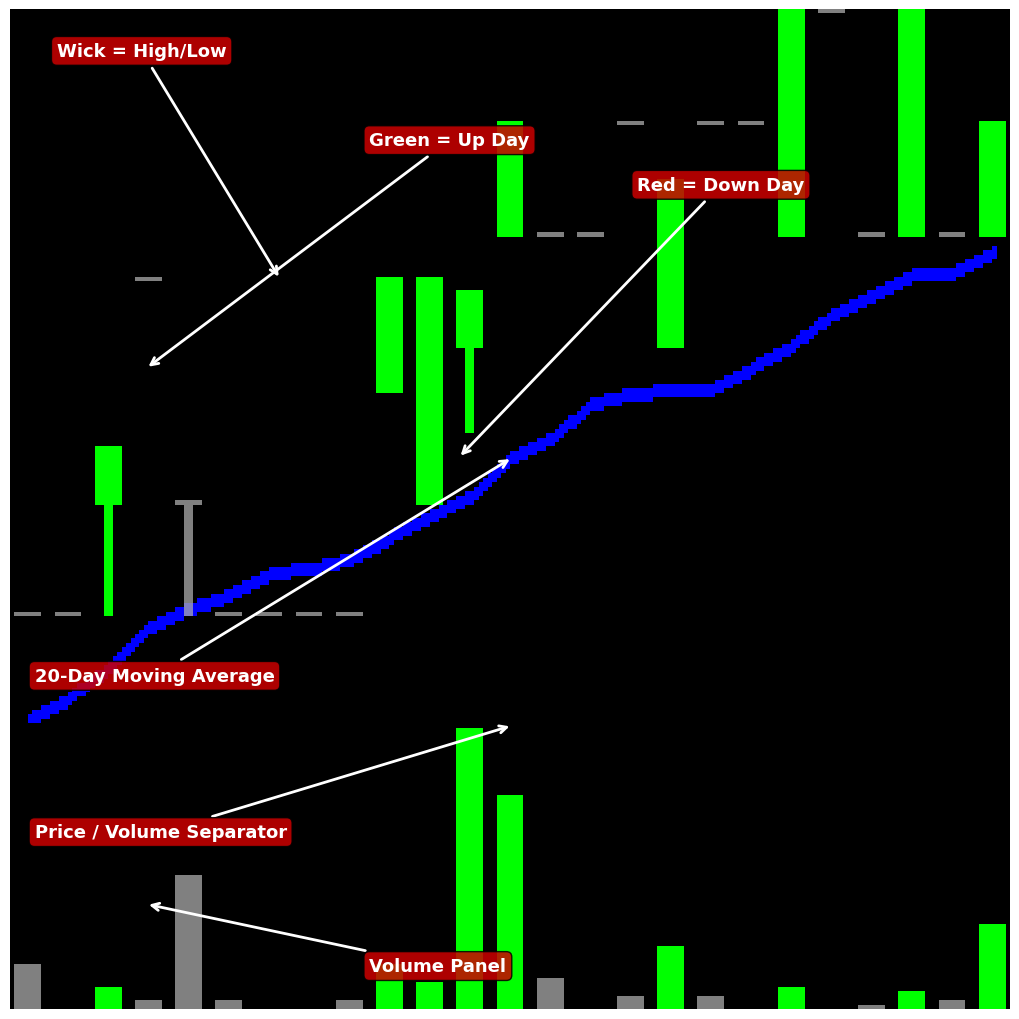

Saved as annotated_chart.png — download from file browser


In [ ]:
# ── Generate annotated candlestick image with arrows for slide 9 ──────────────
# Draws arrows and labels directly onto the chart image using matplotlib
# Save and download for use in PowerPoint slide 9

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Load one image
images = glob('data/image/rgb/**/*.png', recursive=True)
images.sort()
sample_path = images[len(images)//2]
img = Image.open(sample_path).convert('RGB')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(img)
ax.axis('off')

# Arrow style
arrow_props = dict(arrowstyle='->', color='white', lw=2)
text_props  = dict(color='white', fontsize=13, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='#CC0000', alpha=0.85))

# ── Annotations ───────────────────────────────────────────────────────────────
# Green candle body
ax.annotate('Green = Up Day', xy=(30, 80), xytext=(80, 30),
            arrowprops=arrow_props, **text_props)

# Red candle body
ax.annotate('Red = Down Day', xy=(100, 100), xytext=(140, 40),
            arrowprops=arrow_props, **text_props)

# Wick (top)
ax.annotate('Wick = High/Low', xy=(60, 60), xytext=(10, 10),
            arrowprops=arrow_props, **text_props)

# Blue MA20 line — sits roughly in the middle of the price panel
ax.annotate('20-Day Moving Average', xy=(112, 100), xytext=(5, 150),
            arrowprops=arrow_props, **text_props)

# Separator line — row 160 in image coordinates
ax.annotate('Price / Volume Separator', xy=(112, 160), xytext=(5, 185),
            arrowprops=arrow_props, **text_props)

# Volume bar at bottom
ax.annotate('Volume Panel', xy=(30, 200), xytext=(80, 215),
            arrowprops=arrow_props, **text_props)

plt.tight_layout(pad=0)
plt.savefig('annotated_chart.png', dpi=300, bbox_inches='tight',
            facecolor='black', pad_inches=0.1)
plt.show()
print("Saved as annotated_chart.png — download from file browser")